## Grabbing MetaLATTE



In [1]:
%pip install "lightning>=2.4,<3.0"
%pip install "torch==2.9.0"        # or a version available on your mirror
%pip install -e /workarea/AML_Final_Project/MetaLATTE --no-build-isolation --no-deps

import sys
sys.path.append("/workarea/AML_Final_Project/MetaLATTE")

# make sure MetaLATTE is installed into THIS kernel
# after switching the kernel to your .venv, do this in a fresh kernel
import lightning, torch, model
print(lightning.__version__, torch.__version__, model.__file__)


Looking in indexes: https://artprod.dev.bloomberg.com/artifactory/api/pypi/bloomberg-pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://artprod.dev.bloomberg.com/artifactory/api/pypi/bloomberg-pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://artprod.dev.bloomberg.com/artifactory/api/pypi/bloomberg-pypi/simple
Obtaining file:///workarea/AML_Final_Project/MetaLATTE
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for metalatte (pyproject.toml) ... done
  Created wheel for metalatte: filename=metalatte-0.1-0.editable-py3-none-any.whl size=2760 sha256=1100e51c03496d72a56025cc9486832223ebf3fb3da600542b6053b453390887
  Stored in directory: /tmp/pip-ephem-wheel-cache-28hdo3_z/wheels/d9/ae/d6/d162df3b7f5eec99aeba4807cd454d2308eb11f5f278c0517d
Successfully built metalatte
  Attempting uninstall: me

Seed set to 42


2.5.5 2.9.0+cu128 /workarea/AML_Final_Project/MetaLATTE/model.py


In [2]:
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch

def load_model(device=None):
    tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D", trust_remote_code=True)
    config = AutoConfig.from_pretrained("ChatterjeeLab/MetaLATTE", trust_remote_code=True)
    model = AutoModel.from_pretrained("ChatterjeeLab/MetaLATTE", config=config, trust_remote_code=True)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device).eval()
    return tokenizer, model, config, device


## Checking that the model is working

In [3]:
import inspect, importlib, sys, os
mod_path = "/workarea/AML_Final_Project/MetaLATTE/model.py"
spec = importlib.util.spec_from_file_location("metalatte_model", mod_path)
mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)

funcs = [n for n,o in vars(mod).items() if inspect.isfunction(o)]
classes = [n for n,o in vars(mod).items() if inspect.isclass(o)]
print("Functions:", funcs)
print("Classes:", classes)

# For each class, list interesting methods
for n,o in vars(mod).items():
    if inspect.isclass(o):
        meths = [m for m in dir(o) if any(k in m.lower() for k in ("load","from","predict","infer"))]
        if meths:
            print(f"{n} -> {meths}")


Seed set to 42


Functions: ['seed_everything', 'urljoin', 'rotate_half', 'apply_rotary_pos_emb', 'macro_f1', 'safeguard_softmax']
Classes: ['EsmModel', '_LRScheduler', 'PreTrainedModel', 'MetaLATTEConfig', 'GELU', 'RotaryEmbedding', 'PositionalAttentionHead', 'CosineAnnealingWithWarmup', 'RobertaLMHead', 'MultitaskProteinModel']
EsmModel -> ['_fix_state_dict_key_on_load', '_from_config', '_hf_peft_config_loaded', '_keys_to_ignore_on_load_missing', '_keys_to_ignore_on_load_unexpected', '_load_from_flax', '_load_from_state_dict', '_load_from_tf', '_load_pretrained_model', '_move_missing_keys_from_meta_to_cpu', '_register_load_state_dict_pre_hook', '_upload_modified_files', 'from_pretrained', 'load_adapter', 'load_state_dict', 'predict_contacts', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'retrieve_modules_from_names']
_LRScheduler -> ['load_state_dict']
PreTrainedModel -> ['_fix_state_dict_key_on_load', '_from_config', '_hf_peft_config_loaded', '_keys_to_ignore_on_load_mi

In [4]:
os.environ.setdefault("HF_HOME", "/workarea/AML_Final_Project/.hf")
os.environ.setdefault("TRANSFORMERS_CACHE", os.path.join(os.environ["HF_HOME"], "transformers"))
os.environ.setdefault("HF_HUB_CACHE", os.path.join(os.environ["HF_HOME"], "hub"))
os.environ.setdefault("TORCH_HOME", os.path.join(os.environ["HF_HOME"], "torch"))
os.environ.setdefault("XDG_CACHE_HOME", os.environ["HF_HOME"])

# Absolutely no network
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_EVALUATE_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"  # disable special transfer backend
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
os.environ["NO_PROXY"] = "*"
os.environ["no_proxy"] = "*"

## Grabbing and Transforming Outputs

In [1]:
import pandas as pd
base = pd.read_csv("MetaLATTE_Outputs/metalatte_preds_baseline.csv")
metals = [c for c in base.columns if c.startswith("prob_")]
def topk(row, k=3):
    return ", ".join(
        f"{m[5:]}={row[m]:.2f}"
        for m in sorted(metals, key=lambda x: row[x], reverse=True)[:k]
    )
base["top3"] = base.apply(topk, axis=1)
base


,id,sequence,prob_Ag,prob_Cd,prob_Co,prob_Cu,prob_Fe,prob_Hg,prob_Mn,prob_Mo,prob_Ni,prob_Non-binding,prob_Pb,prob_Pt,prob_V,prob_W,prob_Zn,top3
0,sp|P02792|FRIL_HUMAN Ferritin light chain OS=H...,MSSQIRQNYSTDVEAAVNSLVNLYLQASYTYLSLGFYFDRDDVALE...,0.000115,1.606071e-05,2.239675e-05,0.000039,2.721542e-01,0.000025,0.000084,0.000049,0.000027,0.014160,0.000038,2.262822e-06,2.547644e-07,6.789382e-07,0.686051,"Zn=0.69, Fe=0.27, Non-binding=0.01"
1,sp|P02794|FRIH_HUMAN Ferritin heavy chain OS=H...,MTTASTSQVRQNYHQDSEAAINRQINLELYASYVYLSMSYYFDRDD...,0.000178,2.292298e-06,2.020416e-05,0.000066,9.865687e-01,0.000189,0.000301,0.000230,0.000146,0.009881,0.000020,1.734300e-06,1.731233e-07,8.644751e-07,0.003189,"Fe=0.99, Non-binding=0.01, Zn=0.00"
2,sp|P02795|MT2_HUMAN Metallothionein-2 OS=Homo ...,MDPNCSCAAGDSCTCAGSCKCKECKCTSCKKSCCSCCPVGCAKCAQ...,0.005677,9.986184e-01,6.475040e-07,0.000807,5.201820e-07,0.008740,0.000576,0.000101,0.000439,0.015281,0.002664,5.283527e-04,1.269986e-05,2.080038e-04,0.024015,"Cd=1.00, Zn=0.02, Non-binding=0.02"
3,sp|P04732|MT1E_HUMAN Metallothionein-1E OS=Hom...,MDPNCSCATGGSCTCAGSCKCKECKCTSCKKSCCSCCPVGCAKCAQ...,0.006876,9.988801e-01,4.954370e-07,0.001124,5.117004e-07,0.011326,0.000493,0.000107,0.000401,0.014551,0.002822,6.026484e-04,1.281236e-05,2.339937e-04,0.015741,"Cd=1.00, Zn=0.02, Non-binding=0.01"
4,sp|P0A998|FTNA_ECOLI Bacterial non-heme ferrit...,MLKPEMIEKLNEQMNLELYSSLLYQQMSAWCSYHTFEGAAAFLRRH...,0.000159,1.595527e-06,1.518565e-05,0.000047,9.945890e-01,0.000129,0.000119,0.000229,0.000058,0.009871,0.000020,1.826230e-06,1.874535e-07,8.310215e-07,0.009165,"Fe=0.99, Non-binding=0.01, Zn=0.01"
5,sp|P0A9E5|FNR_ECOLI Fumarate and nitrate reduc...,MIPEKRIIRRIQSGGCAIHCQDCSISQLCIPFTLNEHELDQLDNII...,0.000165,9.532787e-07,1.360228e-05,0.000046,9.986455e-01,0.000194,0.000133,0.000310,0.000070,0.008673,0.000016,1.645881e-06,1.618858e-07,8.388437e-07,0.002040,"Fe=1.00, Non-binding=0.01, Zn=0.00"
6,sp|P0A9M0|LON_ECOLI Lon protease OS=Escherichi...,MNPERSERIEIPVLPLRDVVVYPHMVIPLFVGREKSIRCLEAAMDH...,0.000142,1.153556e-03,5.348791e-05,0.000063,1.036325e-04,0.000784,0.608035,0.000054,0.013342,0.010695,0.000073,1.552463e-06,1.177266e-07,7.443250e-07,0.001163,"Mn=0.61, Ni=0.01, Non-binding=0.01"
7,sp|P0ABD3|BFR_ECOLI Bacterioferritin OS=Escher...,MKGDTKVINYLNKLLGNELVAINQYFLHARMFKNWGLKRLNDVEYH...,0.000163,1.341345e-06,1.510097e-05,0.000046,9.967571e-01,0.000123,0.000080,0.000243,0.000052,0.009771,0.000019,1.871591e-06,1.940696e-07,8.393543e-07,0.009862,"Fe=1.00, Zn=0.01, Non-binding=0.01"
8,sp|P0ABT2|DPS_ECOLI DNA protection during star...,MSTAKLVKSKATNLLYTRNDVSDSEKKATVELLNRQVIQFIDLSLI...,0.000114,4.349059e-06,1.483429e-05,0.000028,8.917416e-01,0.000020,0.000017,0.000073,0.000009,0.013512,0.000031,2.305061e-06,2.710490e-07,6.707034e-07,0.745188,"Fe=0.89, Zn=0.75, Non-binding=0.01"
9,sp|P12688|YPK1_YEAST Serine/threonine-protein ...,MYSWKSKFKFGKSKEEKEAKHSGFFHSSKKEEQQNNQATAGEHDAS...,0.000171,3.312519e-03,1.385248e-05,0.000069,1.513265e-04,0.000261,0.007569,0.000028,0.000496,0.014474,0.000091,3.068175e-06,2.576928e-07,1.158253e-06,0.160186,"Zn=0.16, Non-binding=0.01, Mn=0.01"


In [2]:
import pandas as pd
novel = pd.read_csv("MetaLATTE_Outputs/metalatte_preds_novel_MT_v1.csv")
metals = [c for c in novel.columns if c.startswith("prob_")]
def topk(row, k=3):
    return ", ".join(
        f"{m[5:]}={row[m]:.2f}"
        for m in sorted(metals, key=lambda x: row[x], reverse=True)[:k]
    )
novel["top3"] = novel.apply(topk, axis=1)
novel

,id,sequence,prob_Ag,prob_Cd,prob_Co,prob_Cu,prob_Fe,prob_Hg,prob_Mn,prob_Mo,prob_Ni,prob_Non-binding,prob_Pb,prob_Pt,prob_V,prob_W,prob_Zn,top3
0,gen_sp_P04731_MT1A_HUMAN_1,MDPNCSCAEGGSCTCTGSCKCKECKCTSCKESCCSCCPGSCAKCAQ...,0.002631,0.985329,0.000002,0.000465,0.000001,0.004405,0.001201,0.000070,0.000830,0.017039,0.001404,0.000159,5.904121e-06,6.554009e-05,0.065682,"Cd=0.99, Zn=0.07, Non-binding=0.02"
1,gen_sp_P04731_MT1A_HUMAN_2,MTPNCACATGGSCTCTGSCSCYTCKCTSCKKSCCSCCPMSCAKCAQ...,0.002652,0.925739,0.000003,0.000625,0.000005,0.005547,0.001954,0.000097,0.000916,0.018426,0.001268,0.000126,5.093433e-06,5.086921e-05,0.038854,"Cd=0.93, Zn=0.04, Non-binding=0.02"
2,gen_sp_P04731_MT1A_HUMAN_3,MDPQCSCATGGACTCTGSCVCKECKCSSCKKSCCSCCPMSCAKCAP...,0.002368,0.941633,0.000002,0.000762,0.000003,0.003361,0.000935,0.000068,0.000749,0.016564,0.000913,0.000104,3.789334e-06,4.053667e-05,0.056591,"Cd=0.94, Zn=0.06, Non-binding=0.02"
3,gen_sp_P04731_MT1A_HUMAN_4,MDPACSCAAGGSCTCTGSCKCAECKCTSCKKSCCSCCPMSCAKCAP...,0.003308,0.986368,0.000001,0.000925,0.000001,0.004493,0.000829,0.000068,0.000645,0.015731,0.001354,0.000178,5.209880e-06,6.649738e-05,0.045387,"Cd=0.99, Zn=0.05, Non-binding=0.02"
4,gen_sp_P04731_MT1A_HUMAN_5,MDPNCSCAAGGSCTCTASCKCPSCKCTACKKSCCSCCPMSCAKCRQ...,0.002974,0.985696,0.000002,0.000819,0.000001,0.003316,0.000668,0.000062,0.000730,0.016708,0.001249,0.000166,5.550030e-06,6.384844e-05,0.078896,"Cd=0.99, Zn=0.08, Non-binding=0.02"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,gen_tr_Q9JL31_Q9JL31_MOUSE_6,NRPMILIGVLLMLQDSPPASWSNFSWDPLRVRNPSARQCLSDQMES...,0.000091,0.000125,0.000039,0.000040,0.001342,0.000024,0.000989,0.000020,0.000113,0.015417,0.000048,0.000002,1.952837e-07,5.242318e-07,0.752682,"Zn=0.75, Non-binding=0.02, Fe=0.00"
146,gen_tr_Q9JL31_Q9JL31_MOUSE_7,NRPMIDIGVLLMLQDSPPSRWENFSWDPSRVRNPSARQCLSDQMAS...,0.000104,0.000124,0.000050,0.000046,0.001833,0.000037,0.001127,0.000024,0.000301,0.015249,0.000045,0.000002,1.971579e-07,5.332323e-07,0.572032,"Zn=0.57, Non-binding=0.02, Fe=0.00"
147,gen_tr_Q9JL31_Q9JL31_MOUSE_8,NRPMILIGVLKMLQDSPPARDSNFSWDPLAALNPSSRQCLSDQSAS...,0.000097,0.000122,0.000040,0.000043,0.001599,0.000034,0.001419,0.000023,0.000172,0.015289,0.000047,0.000002,1.903331e-07,5.389593e-07,0.597857,"Zn=0.60, Non-binding=0.02, Fe=0.00"
148,gen_tr_Q9JL31_Q9JL31_MOUSE_9,NRPMILEGVLLQLQDSTPARWSNFSWDPARVRNPSARQCLSDQMAS...,0.000128,0.000304,0.000030,0.000042,0.001320,0.000134,0.001748,0.000031,0.000878,0.015192,0.000054,0.000002,2.021027e-07,5.658996e-07,0.318312,"Zn=0.32, Non-binding=0.02, Mn=0.00"


## Plotting the binding capacity for heavy metals in novel

/tmp/ipykernel_282491/2922703560.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


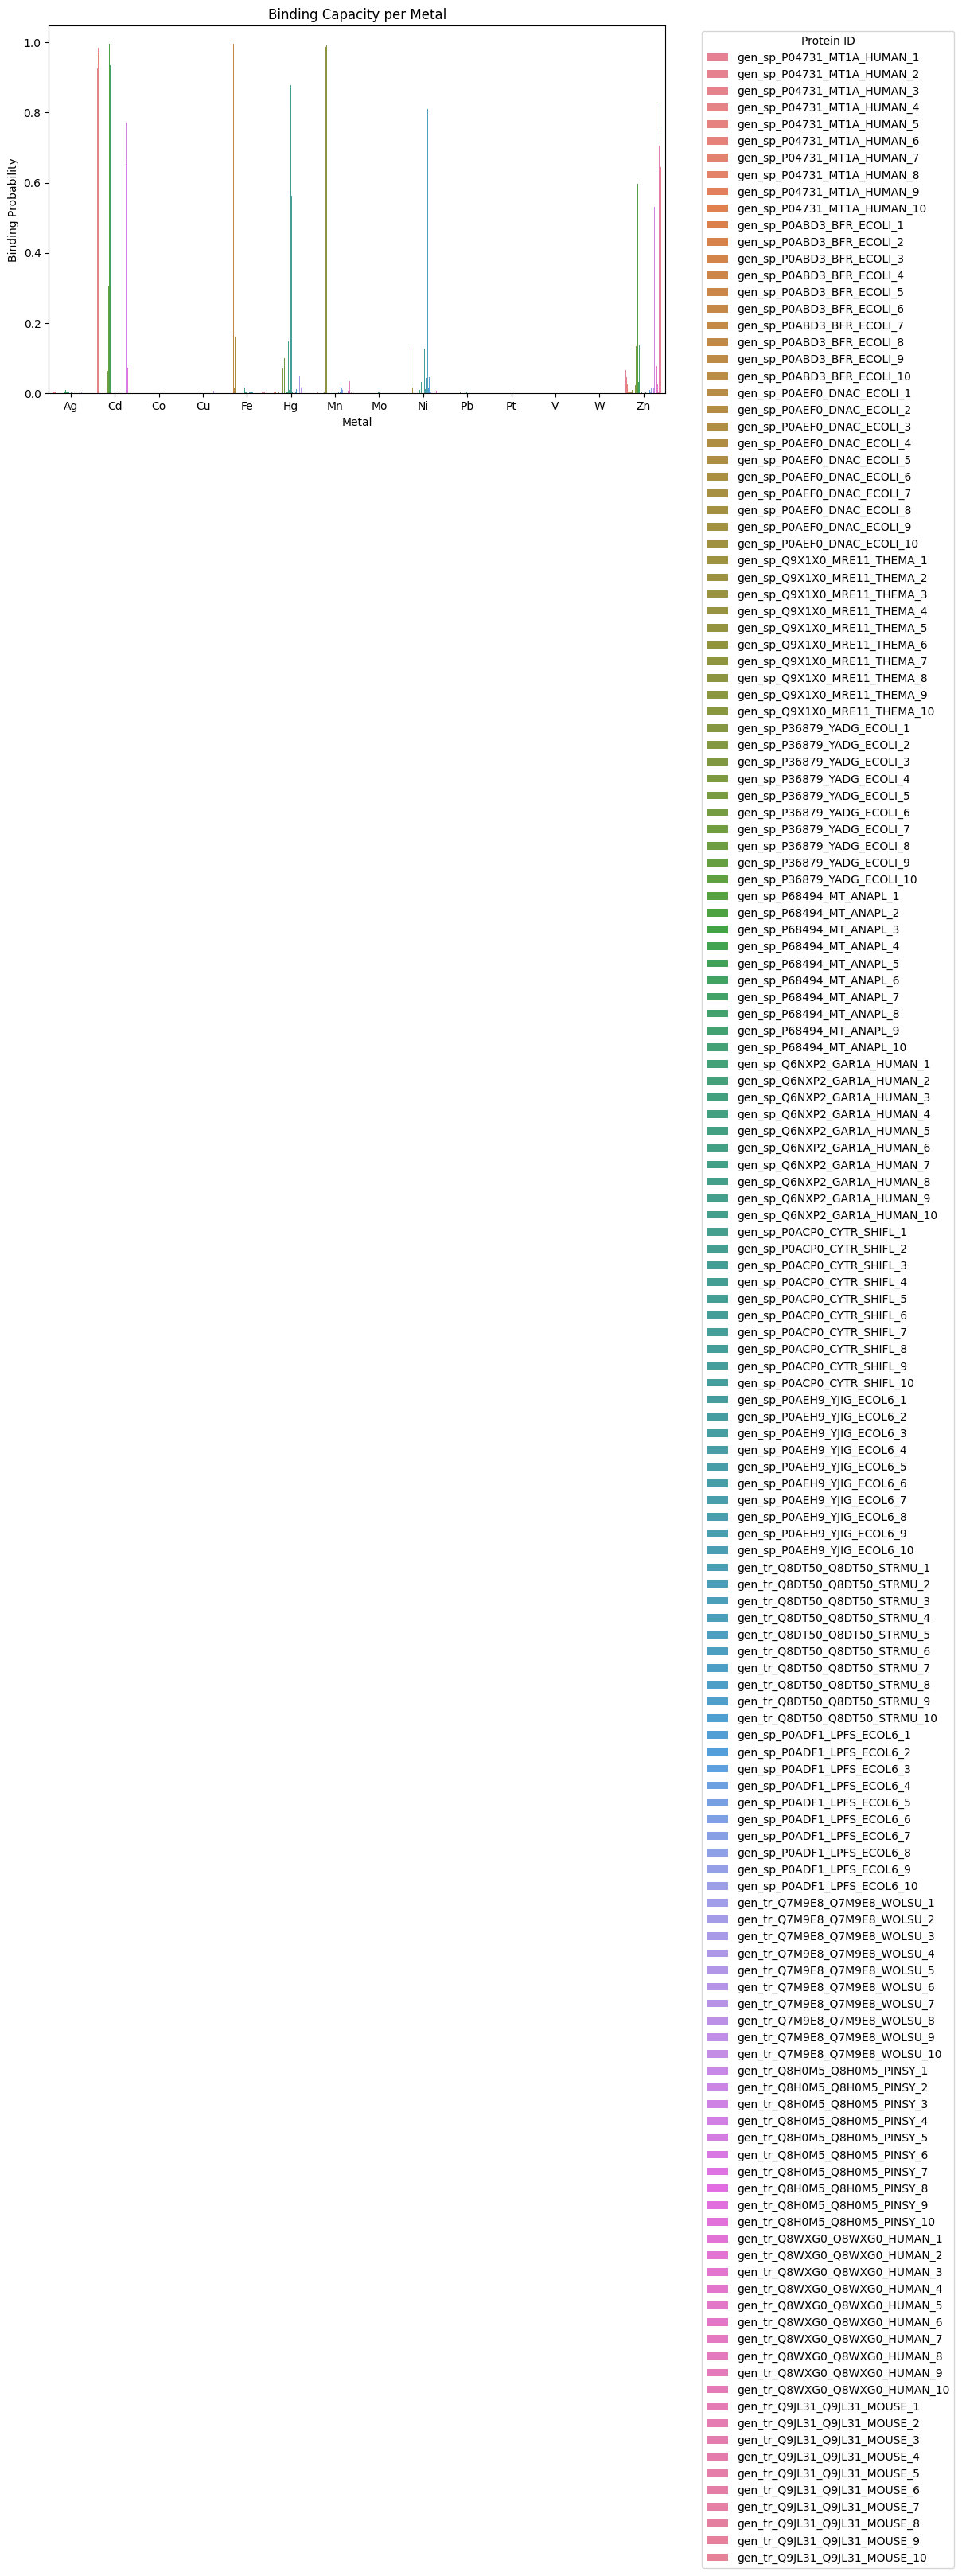

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_capacity(df):
# Suppose your dataframe is df

    # Melt from wide to long format
    df_melted = df.melt(
        id_vars=['id'], 
        value_vars=[col for col in df.columns if col.startswith('prob_') and col != 'prob_Non-binding'],
        var_name='Metal', 
        value_name='Probability'
    )

    # Optional: clean up column names (remove "prob_")
    df_melted['Metal'] = df_melted['Metal'].str.replace('prob_', '')

    # Plot capacity per metal
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_melted,
        x='Metal', 
        y='Probability', 
        hue='id'
    )
    plt.title('Binding Capacity per Metal')
    plt.ylabel('Binding Probability')
    plt.xlabel('Metal')
    plt.legend(title='Protein ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    return plt.show()

plot_capacity(novel)